# Task 1 — Data Analysis

**Objective:** Explore the Spiff dataset to understand structure, patterns, and
relationships in seven simulated financial price series, as preparation for
interpolation (Task 2) and extrapolation (Task 3).

**Dataset:** `data/spiff_data2.csv` — 7 price series (gurkor, guitars,
slingshots, stocks, sugar, water, tranquillity), 5 456 rows. Each series
contains one embedded gap of missing data and is missing its final 200 points.

## 2. Theory

### 2.1 Log-returns

Let $P_t$ denote the observed price at time $t \in \mathbb{Z}$. The
**log-return** at time $t$ is

$$r_t := \log(P_t) - \log(P_{t-1}).$$

We work with log-returns rather than price levels for three reasons:

1. **Variance stabilisation.** Price levels exhibit heteroskedasticity;
   log-returns have approximately constant variance.
2. **Approximate additivity.** $\sum_{k=1}^h r_{t+k} \approx \log(P_{t+h}/P_t)$.
3. **Near-stationarity.** Log-returns of financial series are typically
   weakly stationary; price levels are not.

### 2.2 Weak stationarity

$X = (X_t, t \in \mathbb{Z})$ is **weakly stationary** if

(i) $\mathbb{E}(X_t) = \mu$ for all $t$ (constant mean), and

(ii) $\text{Cov}(X_{t+h}, X_t) = \gamma_X(h)$ for all $t, h \in \mathbb{Z}$
(autocovariance depends only on lag $h$).

### 2.3 ACVF, ACF, sample ACF, and PACF

The **autocovariance function (ACVF)** and **autocorrelation function (ACF)** are

$$\gamma_X(h) := \text{Cov}(X_{t+h}, X_t), \qquad
  \rho_X(h)   := \frac{\gamma_X(h)}{\gamma_X(0)}.$$

Their sample estimators, given $(x_t, t=1,\ldots,n)$, are

$$\hat{\gamma}(h) := n^{-1}\sum_{t=1}^{n-h}(x_{t+h}-\bar{X}_n)(x_t-\bar{X}_n),
  \qquad \hat{\rho}(h) := \frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}.$$

Under the iid null, $\hat{\rho}(h) \approx \text{IID}(0, n^{-1})$ for $h \geq 1$,
giving 95% Bartlett bands $\pm 1.96/\sqrt{n}$.

The **partial autocorrelation function (PACF)** $\alpha_X(h)$ is the correlation
between $X_t$ and $X_{t+h}$ after removing the linear effect of
$X_{t+1}, \ldots, X_{t+h-1}$.

### 2.4 Augmented Dickey–Fuller (ADF) test

$H_0$: unit root (non-stationary). $H_1$: stationary. The test fits

$$\Delta x_t = \alpha + \delta x_{t-1} + \sum_{j=1}^p \phi_j \Delta x_{t-j} + Z_t,$$

with $p$ chosen by AIC. We reject $H_0$ at $\alpha = 0.05$ when the $p$-value
is below that threshold.

**Policy:** Seasonal differencing is **not** applied by default. First-differencing
is applied reactively only if a return series fails the ADF test, with the
decision recorded in `docs/DECISIONS.md`.

### 2.5 Ljung–Box test

Tests $H_0$: $\rho_X(1) = \cdots = \rho_X(h) = 0$ against at least one
non-zero autocorrelation. Statistic:

$$\lambda := n(n+2)\sum_{i=1}^h \frac{\hat{\rho}(i)^2}{n-i},$$

asymptotically $\chi^2_h$ under $H_0$. Applied to $r_t^2$, it detects
**volatility clustering** (ARCH effects).

### 2.6 Cross-correlation

$$\rho_{XY}(h) := \frac{\text{Cov}(X_{t+h}, Y_t)}
                       {\sqrt{\text{Var}(X_t)\,\text{Var}(Y_t)}}.$$

Note $\rho_{XY}(h) \neq \rho_{XY}(-h)$ in general.\


In [2]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import adfuller, acf, pacf, ccf
from statsmodels.stats.diagnostic import acorr_ljungbox

from utils import (load_data, get_gap_info, compute_log_returns,
                   set_plot_style, savefig, SERIES, TRAILING_N, SERIES_COLOURS)

np.random.seed(42)
set_plot_style()

DATA_PATH = '../data/spiff_data2.csv'

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

## 4. Load and inspect the data

`load_data()` reads the CSV and replaces the five anomalous rows (all series
= 1 000.0) with `NaN`. Section 5 documents this decision.

In [ ]:
df = load_data(DATA_PATH)
print(f"Shape: {df.shape}  ({df.shape[0]} rows x {df.shape[1]} columns)")
print(f"\nColumn dtypes:\n{df.dtypes.to_string()}")
print("\nFirst 3 rows:")
display(df.head(3))
print("\nSummary statistics (price levels):")
display(df[SERIES].describe().round(4))

Shape: (5456, 8)  (5456 rows x 8 columns)

Column dtypes:
day               int64
gurkor          float64
guitars         float64
slingshots      float64
stocks          float64
sugar           float64
water           float64
tranquillity    float64

First 3 rows:


,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
1,2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
2,3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205



Summary statistics (price levels):


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5201.0000,5201.0000,5201.0000,5201.0000,5201.0000,5201.0000,5201.0000
mean,8.9347,5.7590,3.5625,6.3548,2.6635,5.7946,11.5529
std,2.2683,1.7570,0.9734,2.1394,0.7270,1.2750,3.0676
min,5.9429,2.6290,2.0014,4.0123,1.3703,3.7394,6.6147
25%,6.9471,4.2527,2.8049,4.9169,1.9990,4.9966,9.1863
50%,8.9055,5.9078,3.3831,5.5205,2.6055,5.7749,10.5849
75%,10.1839,7.0556,4.2914,6.9464,3.2800,6.4882,13.3805
max,14.1324,10.7194,6.4690,13.6131,4.1252,8.9492,21.1380


In [ ]:
df_raw = pd.read_csv(DATA_PATH, index_col=0)
anomaly_mask = (df_raw[SERIES] == 1000.0).any(axis=1)
print(f"Rows with any value == 1000.0 in raw data: {anomaly_mask.sum()}")
display(df_raw.loc[anomaly_mask, ['day'] + SERIES])

Rows with any value == 1000.0 in raw data: 5


,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
35,36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1193,1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2835,2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3429,3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4117,4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


## 6. Gap and missing-data structure

Each series has two distinct NaN regions:

1. **Embedded gap** — a contiguous interior block targeted by Task 2
   (interpolation).
2. **Trailing window** — the final 200 rows, held out for Task 3
   (extrapolation) evaluation.

In [ ]:
gap_info = get_gap_info(df)

rows = []
for s, info in gap_info.items():
    rows.append({
        'Series':               s,
        'Gap start (row)':      info['gap_start'],
        'Gap end (row)':        info['gap_end'],
        'Gap length':           info['gap_len'],
        'Contiguous':           info['contiguous'],
        'Trailing start (row)': info['trailing_start'],
        'Trailing length':      info['trailing_len'],
    })

display(pd.DataFrame(rows).set_index('Series'))

NameError: name 'get_gap_info' is not defined

## 5. Anomaly detection

Five rows in the raw data have every series simultaneously equal to
exactly **1 000.0** — a systematic recording artefact (unrelated assets do not
take the same round value at the same time). These rows are replaced with `NaN`
by `load_data()` to prevent spurious log-returns at those boundaries.

In [ ]:
print("Same rows after load_data() — all series are now NaN:")
display(df.loc[anomaly_mask, ['day'] + SERIES])

Same rows after load_data() — all series are now NaN:


,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
35,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1193,1194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2835,2836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3429,3430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4117,4118,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Train / test split

All statistical analysis is performed on the **training set only** (rows 0–5 255).
The test set (final 200 rows) is sealed here and never used in this notebook.

**Why split first?** Computing statistics on all available data (including the
test window) would encode future information into model parameters —
*look-ahead bias*. Keeping the test set clean ensures that performance
estimates in Tasks 2 and 3 are genuinely out-of-sample.

In [ ]:
split_idx = len(df) - TRAILING_N   # 5256
df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

print(f"Training set: rows 0-{split_idx-1}  ({len(df_train)} observations)")
print(f"Test set:     rows {split_idx}-{len(df)-1}  ({len(df_test)} observations)")
print("\ndf_test is sealed — not used in this notebook.")

Training set: rows 0-5255  (5256 observations)
Test set:     rows 5256-5455  (200 observations)

df_test is sealed — not used in this notebook.


## 8. Price level plots (training set)

Red shading marks each series' embedded gap. The trailing test window is
excluded (it is entirely NaN in the training set).

In [ ]:
gap_info_train = get_gap_info(df_train)

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for i, col in enumerate(SERIES):
    ax = axes[i]
    ax.plot(df_train['day'], df_train[col], lw=0.7, color=SERIES_COLOURS[col])
    info = gap_info_train[col]
    labeled = False
    for run in info['nan_runs']:
        if len(run) < 2:
            continue
        d0 = df_train.loc[run[0], 'day']
        d1 = df_train.loc[run[-1], 'day']
        ax.axvspan(d0, d1, alpha=0.2, color='gray',
                   label='Embedded gap' if not labeled else '_nolegend_')
        labeled = True
    ax.set_ylabel('Price', fontsize=10)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

for ax in axes[6:]:
    ax.set_xlabel('Day')
axes[-1].set_visible(False)

fig.suptitle('Price Levels — Training Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Log-return computation

Log-returns $r_t := \log(P_t) - \log(P_{t-1})$ are computed on the training
set via `compute_log_returns()`. NaN gaps are preserved: the return immediately
after each gap is NaN, preventing a spurious large return at the boundary.\


In [ ]:
returns_train = compute_log_returns(df_train)
print(f"Returns shape: {returns_train.shape}")
print("\nFirst 5 rows:")
display(returns_train.head())

Returns shape: (5256, 8)

First 5 rows:


,day,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.005666,0.017307,-0.010802,0.001949,0.009233,0.000966,0.003273
2,3,-0.003396,-0.001205,0.001302,0.013761,-0.005760,-0.000644,0.013390
3,4,-0.001986,-0.005743,-0.009590,0.002439,-0.014548,0.000966,-0.004848
4,5,-0.005125,0.003329,0.001751,0.001099,0.004678,0.001072,0.004445


## 10. Log-return plots (training set)

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for i, col in enumerate(SERIES):
    ax = axes[i]
    ax.plot(returns_train['day'], returns_train[col],
            lw=0.5, alpha=0.8, color=SERIES_COLOURS[col])
    ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    ax.set_ylabel(r'$r_t$', fontsize=10)
    ax.set_title(col, fontsize=12, fontweight='bold')

for ax in axes[6:]:
    ax.set_xlabel('Day')
axes[-1].set_visible(False)

fig.suptitle('Log-Returns — Training Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Descriptive statistics

Excess kurtosis > 0 indicates heavier tails than a normal distribution
(leptokurtosis) — a common feature of financial returns.

In [ ]:
stats_rows = {}
for col in SERIES:
    r = returns_train[col].dropna().values
    stats_rows[col] = {
        'N':               len(r),
        'Mean':            np.mean(r),
        'Std':             np.std(r, ddof=1),
        'Skewness':        skew(r),
        'Excess kurtosis': kurtosis(r),
        'Min':             np.min(r),
        'Max':             np.max(r),
    }

display(pd.DataFrame(stats_rows).T.round(4))

,N,Mean,Std,Skewness,Excess kurtosis,Min,Max
gurkor,5194.0,0.0002,0.0039,-0.1469,3.5131,-0.0248,0.0363
guitars,5194.0,0.0002,0.0149,-0.0349,5.5522,-0.0931,0.1225
slingshots,5194.0,0.0002,0.0147,-0.4449,6.4314,-0.1219,0.0925
stocks,5194.0,-0.0001,0.0149,-0.1242,0.0760,-0.0605,0.0517
sugar,5194.0,-0.0000,0.0152,-0.2385,10.6935,-0.1412,0.1892
water,5194.0,0.0002,0.0035,-0.2596,2.2468,-0.0261,0.0173
tranquillity,5194.0,0.0001,0.0126,-0.2718,2.9726,-0.0867,0.0598


## 12. Stationarity — Augmented Dickey–Fuller tests

Applied to log-returns (training set). Lags selected by AIC.
See Section 2.4 for the null hypothesis and policy on differencing.

In [ ]:
def run_adf(values, alpha=0.05):
    stat, pval, lags, *_ = adfuller(values, autolag='AIC')
    return {
        'ADF statistic':       round(stat,  4),
        'p-value':             round(pval,  4),
        'Lags used':           lags,
        f'Reject H0 (a={alpha})': pval < alpha,
    }

adf_rows = {col: run_adf(returns_train[col].dropna().values) for col in SERIES}
display(pd.DataFrame(adf_rows).T)

,ADF statistic,p-value,Lags used,Reject H0 (a=0.05)
gurkor,-53.1885,0.0,1,True
guitars,-12.1853,0.0,29,True
slingshots,-19.1148,0.0,13,True
stocks,-72.1206,0.0,0,True
sugar,-36.8048,0.0,3,True
water,-43.1526,0.0,2,True
tranquillity,-73.5667,0.0,0,True


\
## 13. ACF, PACF, and Ljung–Box test on returns

Dashed red lines are Bartlett 95% bands $\pm 1.96/\sqrt{n}$.\


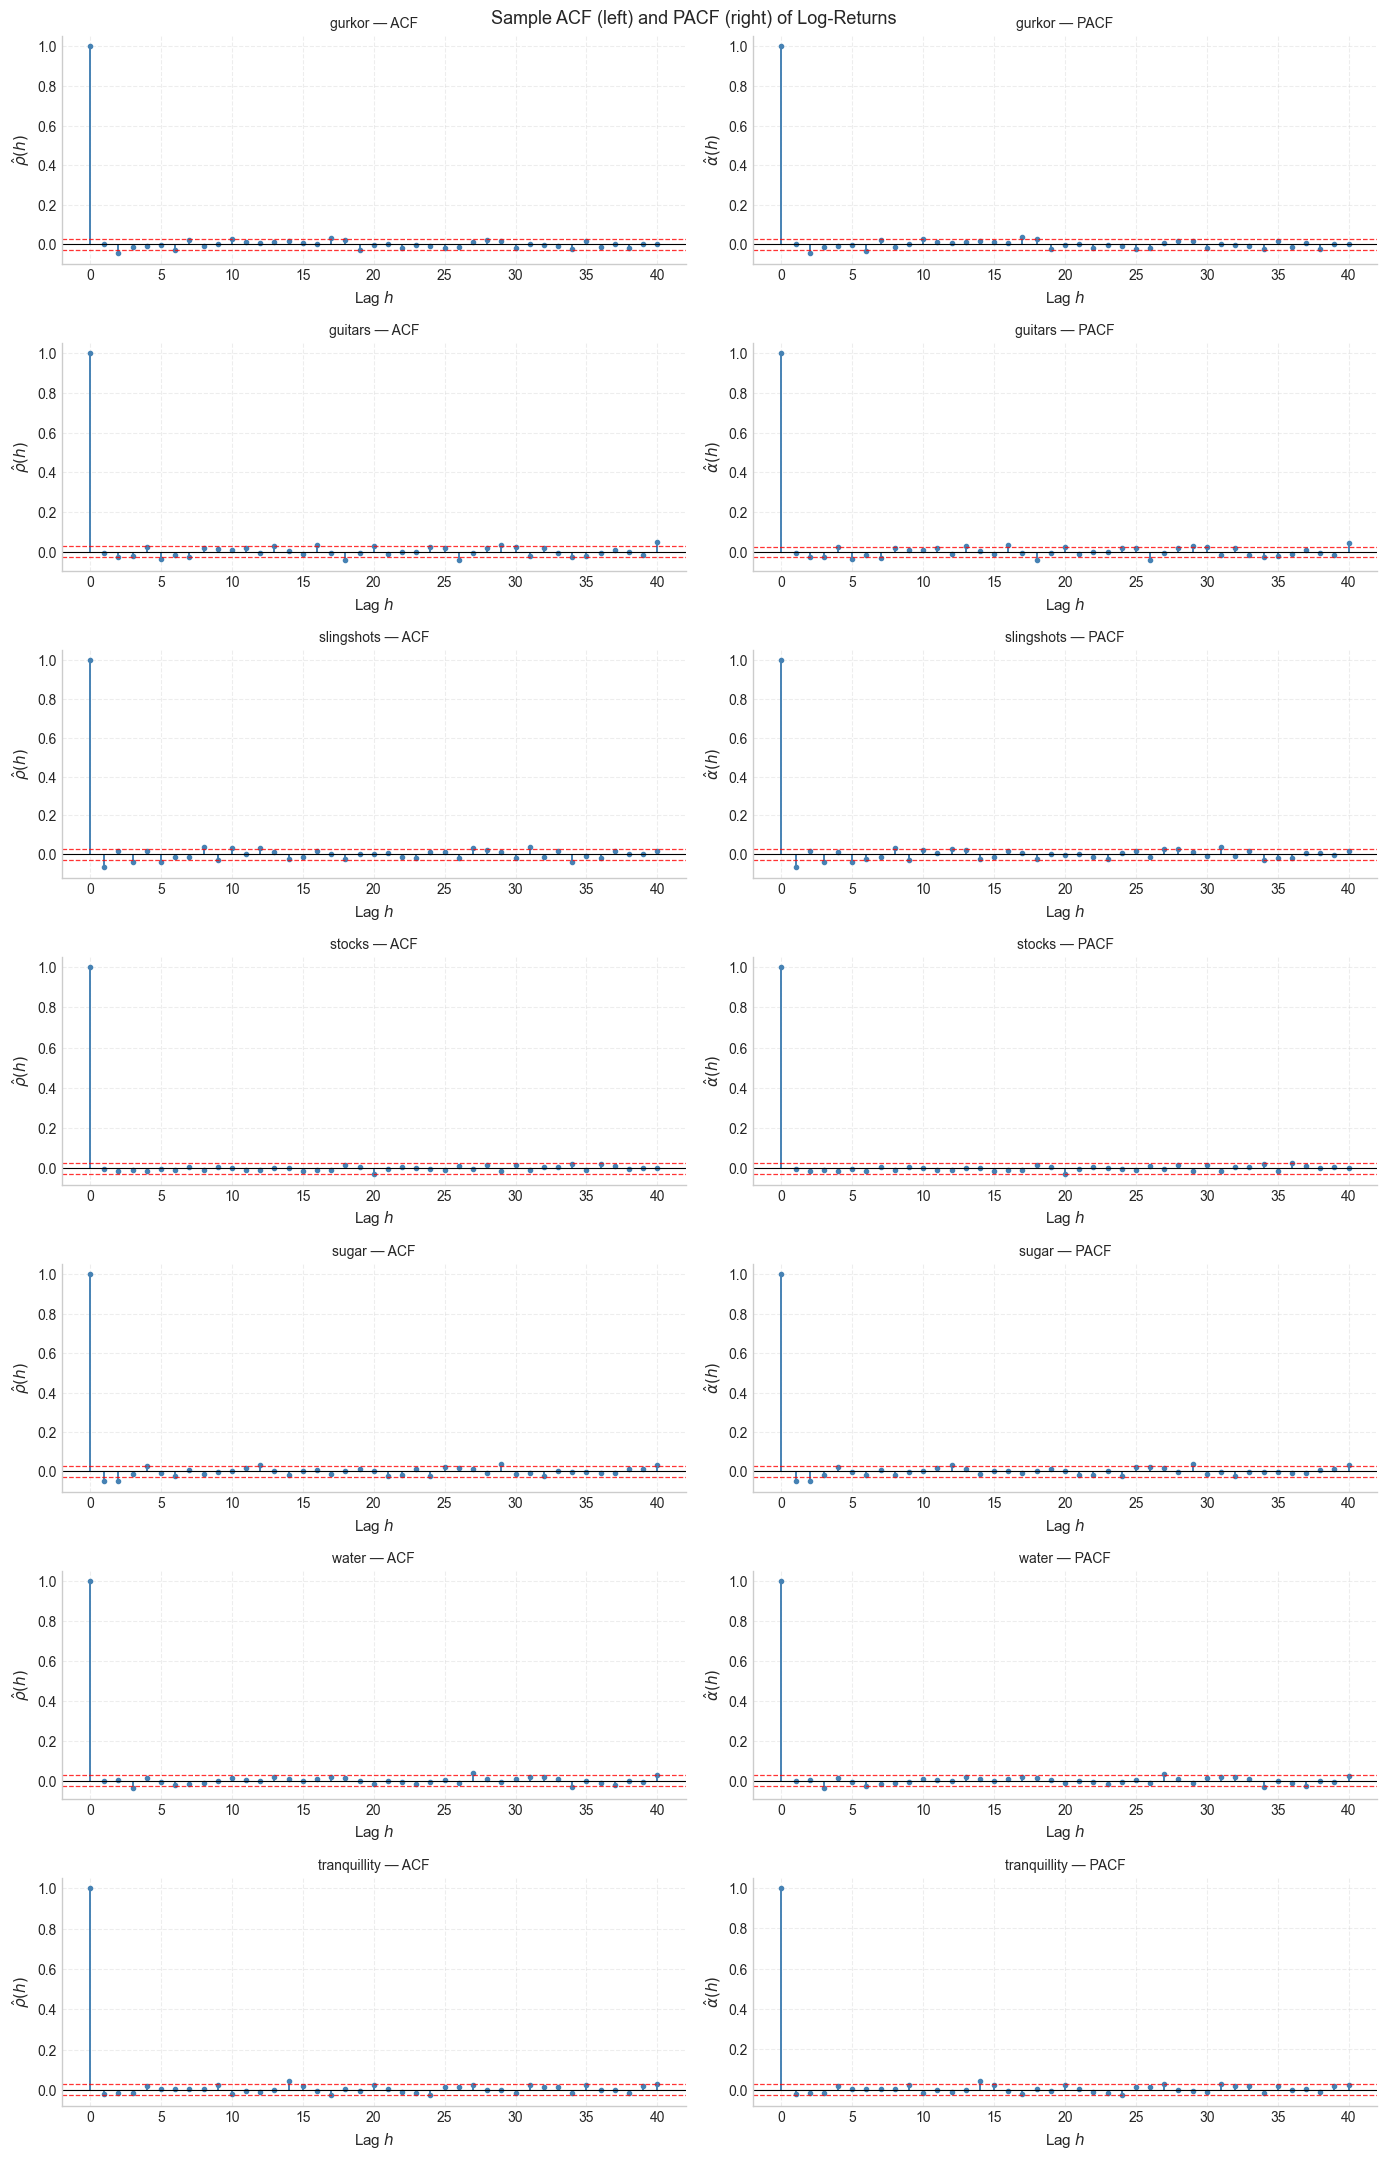

In [ ]:
NLAGS = 40

fig, axes = plt.subplots(7, 2, figsize=(14, 22))
fig.suptitle('Sample ACF (left) and PACF (right) of Log-Returns', fontsize=13)

for i, col in enumerate(SERIES):
    r = returns_train[col].dropna().values
    n = len(r)
    conf = 1.96 / np.sqrt(n)
    lags = np.arange(NLAGS + 1)

    acf_vals  = acf(r,  nlags=NLAGS, fft=True)
    pacf_vals = pacf(r, nlags=NLAGS, method='ywm')

    for j, (vals, ylabel, suffix) in enumerate([
        (acf_vals,  r'$\hat{\rho}(h)$',   'ACF'),
        (pacf_vals, r'$\hat{\alpha}(h)$', 'PACF'),
    ]):
        ax = axes[i, j]
        ax.vlines(lags, 0, vals, colors='steelblue', lw=1.4)
        ax.plot(lags, vals, 'o', ms=3, color='steelblue')
        ax.axhline(0,     color='black', lw=0.8)
        ax.axhline( conf, ls='--', color='red', lw=0.9, alpha=0.8)
        ax.axhline(-conf, ls='--', color='red', lw=0.9, alpha=0.8)
        ax.set_title(f'{col} — {suffix}', fontsize=10)
        ax.set_xlabel('Lag $h$')
        ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

In [ ]:
lb_rows = {}
for col in SERIES:
    r  = returns_train[col].dropna().values
    lb = acorr_ljungbox(r, lags=[10, 20], return_df=True)
    lb_rows[col] = {
        'LB stat (h=10)': round(lb.loc[10, 'lb_stat'],   3),
        'p-val  (h=10)':  round(lb.loc[10, 'lb_pvalue'], 4),
        'LB stat (h=20)': round(lb.loc[20, 'lb_stat'],   3),
        'p-val  (h=20)':  round(lb.loc[20, 'lb_pvalue'], 4),
    }

print("Ljung-Box test on log-returns:")
display(pd.DataFrame(lb_rows).T)

Ljung-Box test on log-returns:


,LB stat (h=10),p-val (h=10),LB stat (h=20),p-val (h=20)
gurkor,24.292,0.0069,41.821,0.0029
guitars,24.792,0.0058,50.262,0.0002
slingshots,64.073,0.0000,78.169,0.0000
stocks,4.267,0.9345,12.476,0.8987
sugar,33.069,0.0003,43.072,0.0020
water,15.468,0.1159,22.077,0.3363
tranquillity,11.903,0.2916,31.022,0.0549


\
## 14. Volatility clustering

Autocorrelation in squared returns $r_t^2$ signals ARCH effects —
large moves tend to cluster together.\


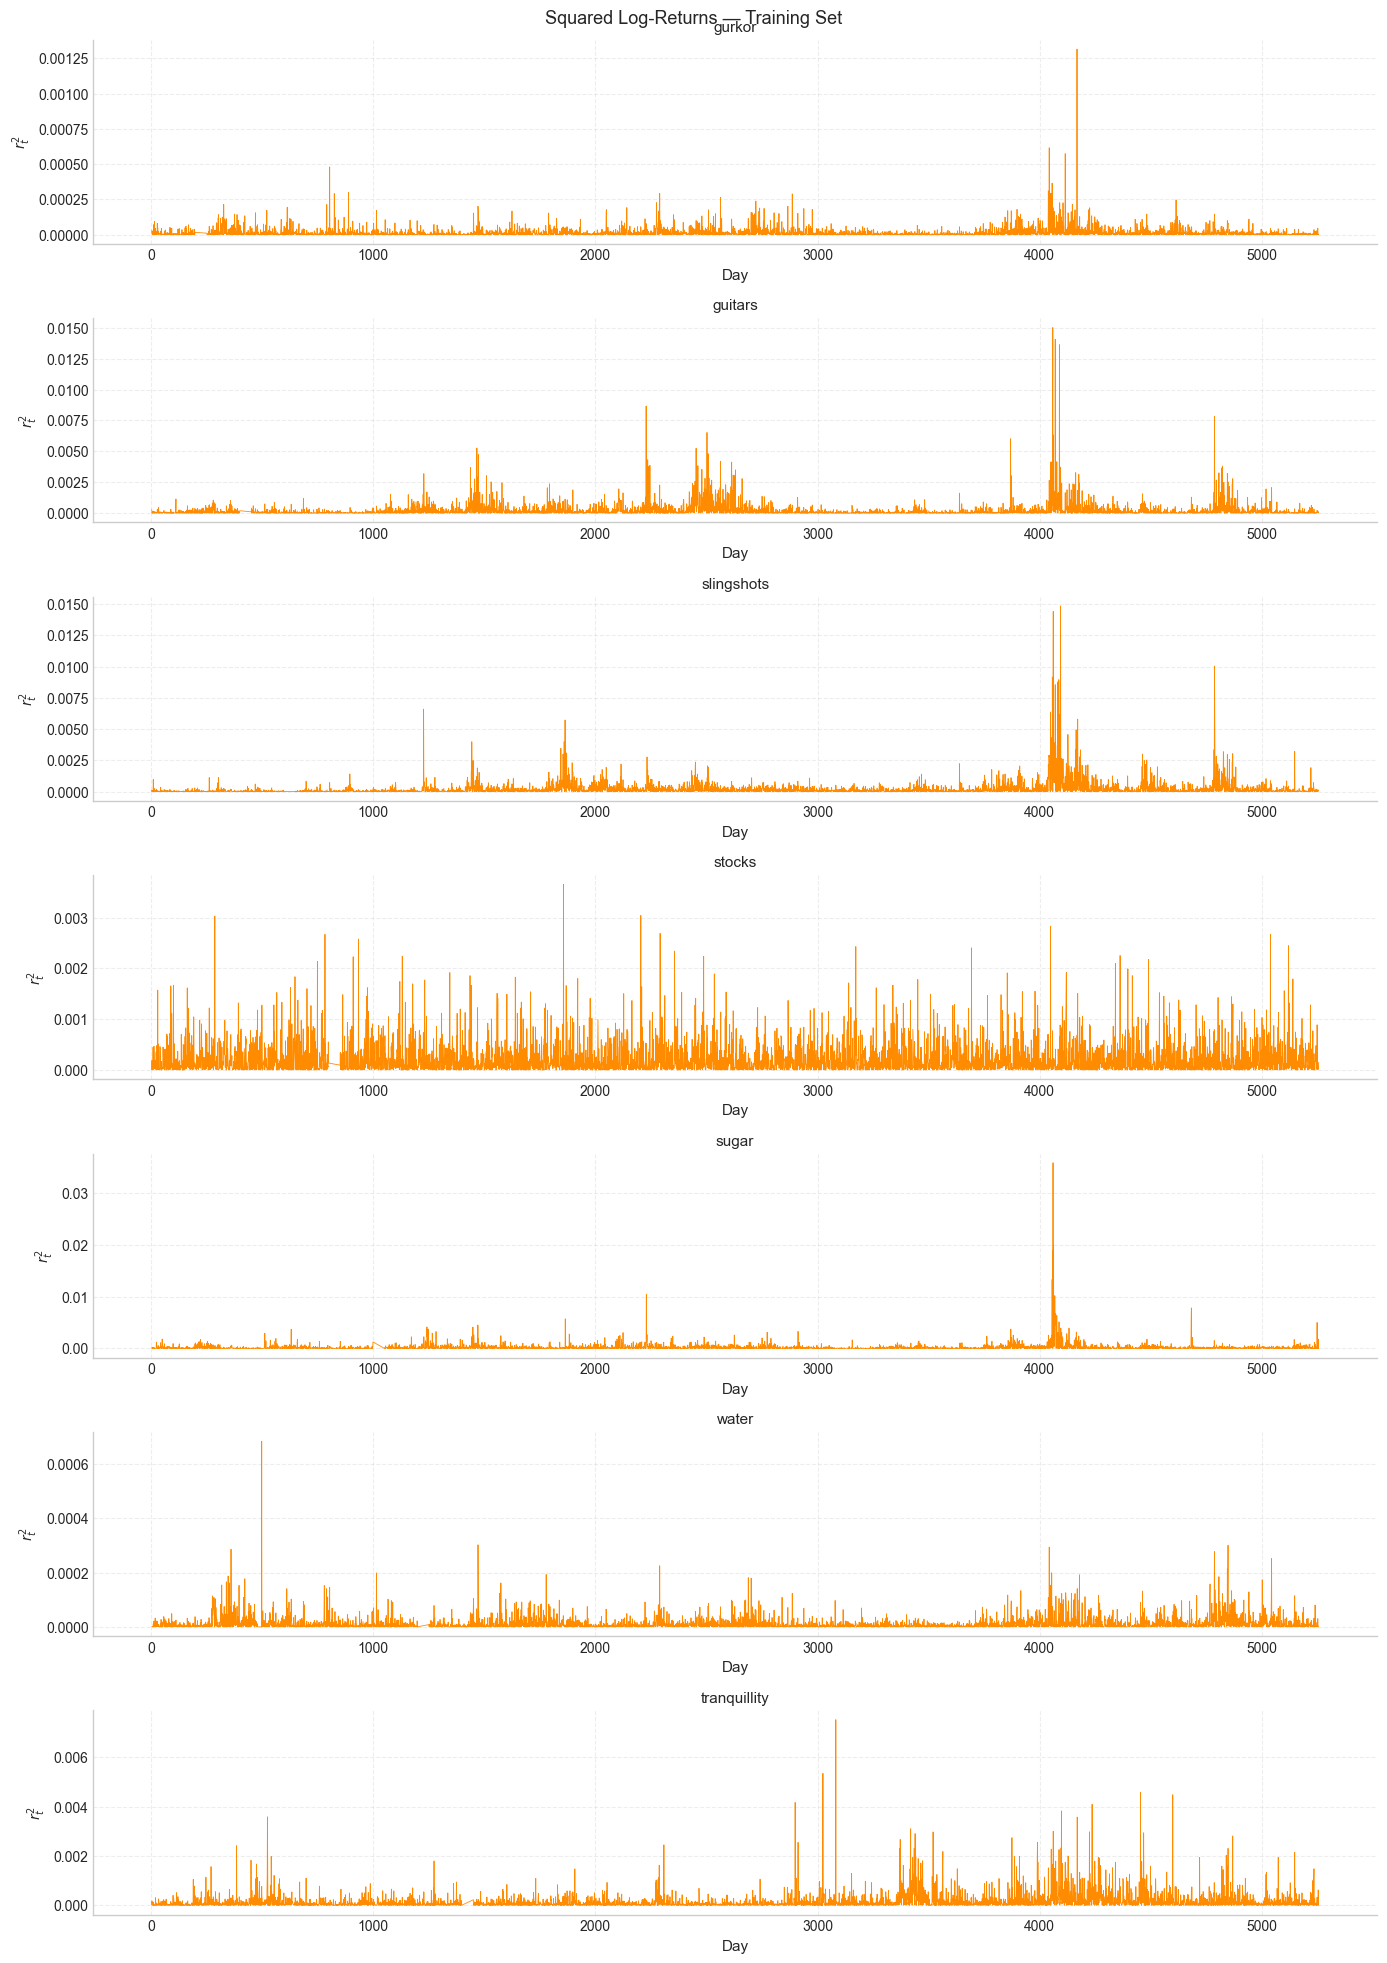

In [ ]:
fig, axes = plt.subplots(7, 1, figsize=(14, 20))
fig.suptitle('Squared Log-Returns — Training Set', fontsize=13)

for ax, col in zip(axes, SERIES):
    r = returns_train[col]
    valid = r.notna()
    ax.plot(returns_train.loc[valid, 'day'], r[valid] ** 2,
            lw=0.6, color='darkorange')
    ax.set_ylabel(r'$r_t^2$', fontsize=10)
    ax.set_xlabel('Day')
    ax.set_title(col, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
lb_sq_rows = {}
for col in SERIES:
    r2 = returns_train[col].dropna().values ** 2
    lb = acorr_ljungbox(r2, lags=[10, 20], return_df=True)
    lb_sq_rows[col] = {
        'LB stat (h=10)':       round(lb.loc[10, 'lb_stat'],   3),
        'p-val  (h=10)':        round(lb.loc[10, 'lb_pvalue'], 4),
        'LB stat (h=20)':       round(lb.loc[20, 'lb_stat'],   3),
        'p-val  (h=20)':        round(lb.loc[20, 'lb_pvalue'], 4),
        'ARCH effect (a=0.05)': lb.loc[10, 'lb_pvalue'] < 0.05,
    }

print("Ljung-Box test on squared log-returns:")
display(pd.DataFrame(lb_sq_rows).T)

Ljung-Box test on squared log-returns:


,LB stat (h=10),p-val (h=10),LB stat (h=20),p-val (h=20),ARCH effect (a=0.05)
gurkor,364.343,0.0,699.345,0.0,True
guitars,2067.539,0.0,3816.199,0.0,True
slingshots,4827.406,0.0,8173.363,0.0,True
stocks,7.157,0.7105,17.747,0.6041,False
sugar,3928.037,0.0,4921.07,0.0,True
water,465.359,0.0,845.876,0.0,True
tranquillity,661.908,0.0,1255.539,0.0,True


## 14b. Regime detection — rolling mean and volatility

A 60-day rolling mean and rolling standard deviation reveal whether the
first two moments shift over time. Dashed lines show the full-sample values
as reference.

**Note:** No formal breakpoint test is applied here. Visible regime shifts
would motivate a Markov-switching model or time-varying GARCH in Tasks 2/3.

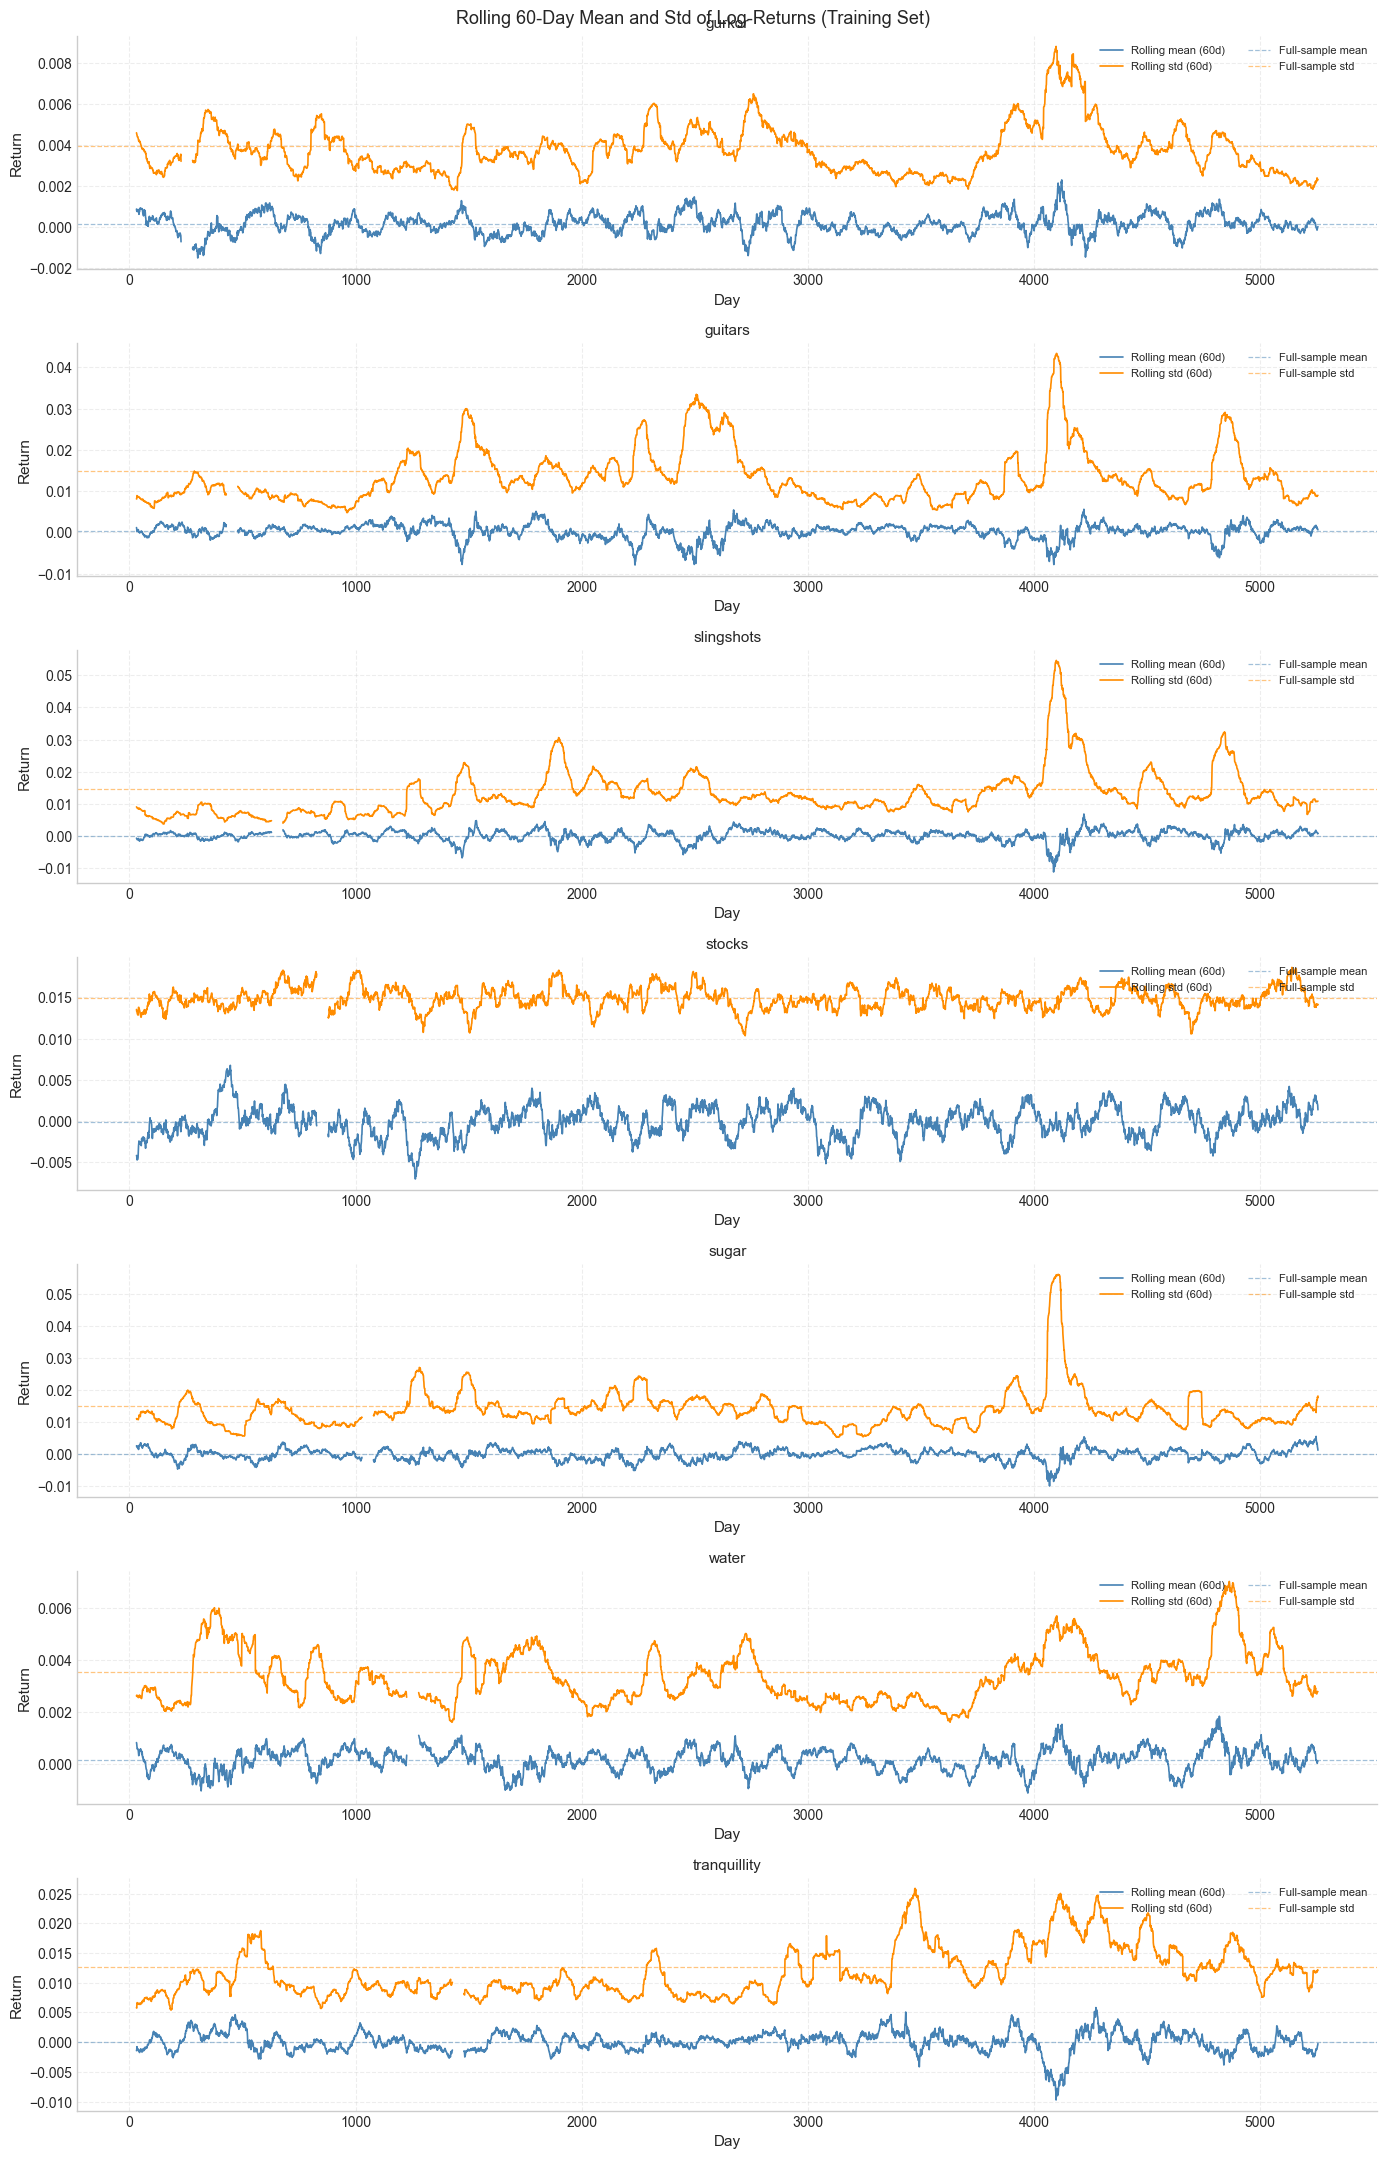

In [ ]:
WINDOW = 60

fig, axes = plt.subplots(7, 1, figsize=(14, 22))
fig.suptitle(f'Rolling {WINDOW}-Day Mean and Std of Log-Returns (Training Set)',
             fontsize=13)

for ax, col in zip(axes, SERIES):
    r    = returns_train[col]
    days = returns_train['day']

    roll_mean = r.rolling(WINDOW, min_periods=WINDOW // 2).mean()
    roll_std  = r.rolling(WINDOW, min_periods=WINDOW // 2).std()

    ax.plot(days, roll_mean, color='steelblue',  lw=1.2,
            label=f'Rolling mean ({WINDOW}d)')
    ax.plot(days, roll_std,  color='darkorange', lw=1.2,
            label=f'Rolling std ({WINDOW}d)')
    ax.axhline(r.mean(), ls='--', color='steelblue',  lw=0.9, alpha=0.5,
               label='Full-sample mean')
    ax.axhline(r.std(),  ls='--', color='darkorange', lw=0.9, alpha=0.5,
               label='Full-sample std')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Day')
    ax.set_ylabel('Return')
    ax.legend(fontsize=8, ncol=2, loc='upper right')

plt.tight_layout()
plt.show()

## 15. Cross-series correlation

Pairwise Pearson correlation of log-returns (training set, pairwise complete
observations). Cross-correlation functions (CCF) are shown for pairs with
$|\hat{\rho}| > 0.5$.

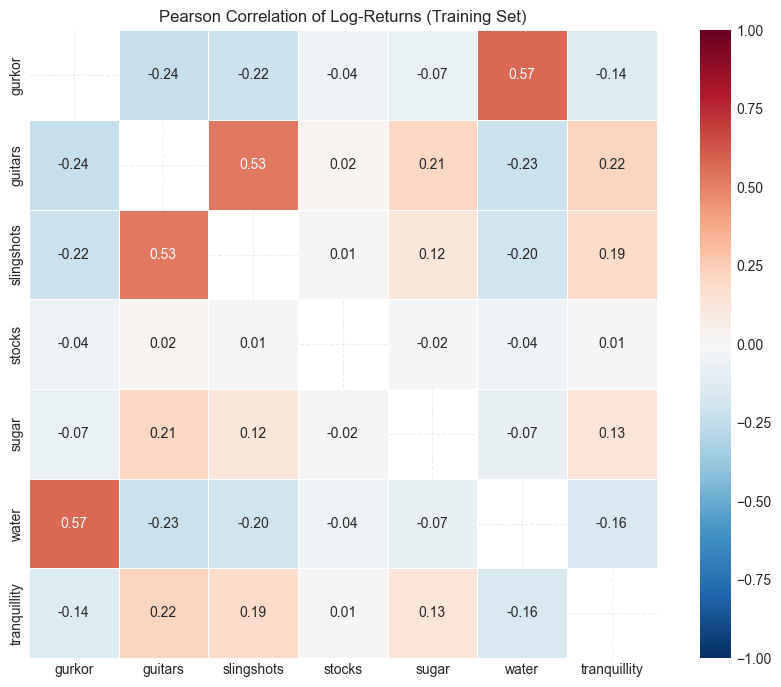

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000,-0.241,-0.217,-0.042,-0.067,0.573,-0.138
guitars,-0.241,1.000,0.526,0.016,0.212,-0.226,0.224
slingshots,-0.217,0.526,1.000,0.013,0.118,-0.201,0.189
stocks,-0.042,0.016,0.013,1.000,-0.016,-0.042,0.010
sugar,-0.067,0.212,0.118,-0.016,1.000,-0.071,0.127
water,0.573,-0.226,-0.201,-0.042,-0.071,1.000,-0.158
tranquillity,-0.138,0.224,0.189,0.010,0.127,-0.158,1.000


In [ ]:
corr_matrix = returns_train[SERIES].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            mask=np.eye(len(SERIES), dtype=bool),
            ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Pearson Correlation of Log-Returns (Training Set)')
plt.tight_layout()
plt.show()
display(corr_matrix.round(3))

Pairs with |rho| > 0.5:
  gurkor vs water: rho = 0.573
  guitars vs slingshots: rho = 0.526


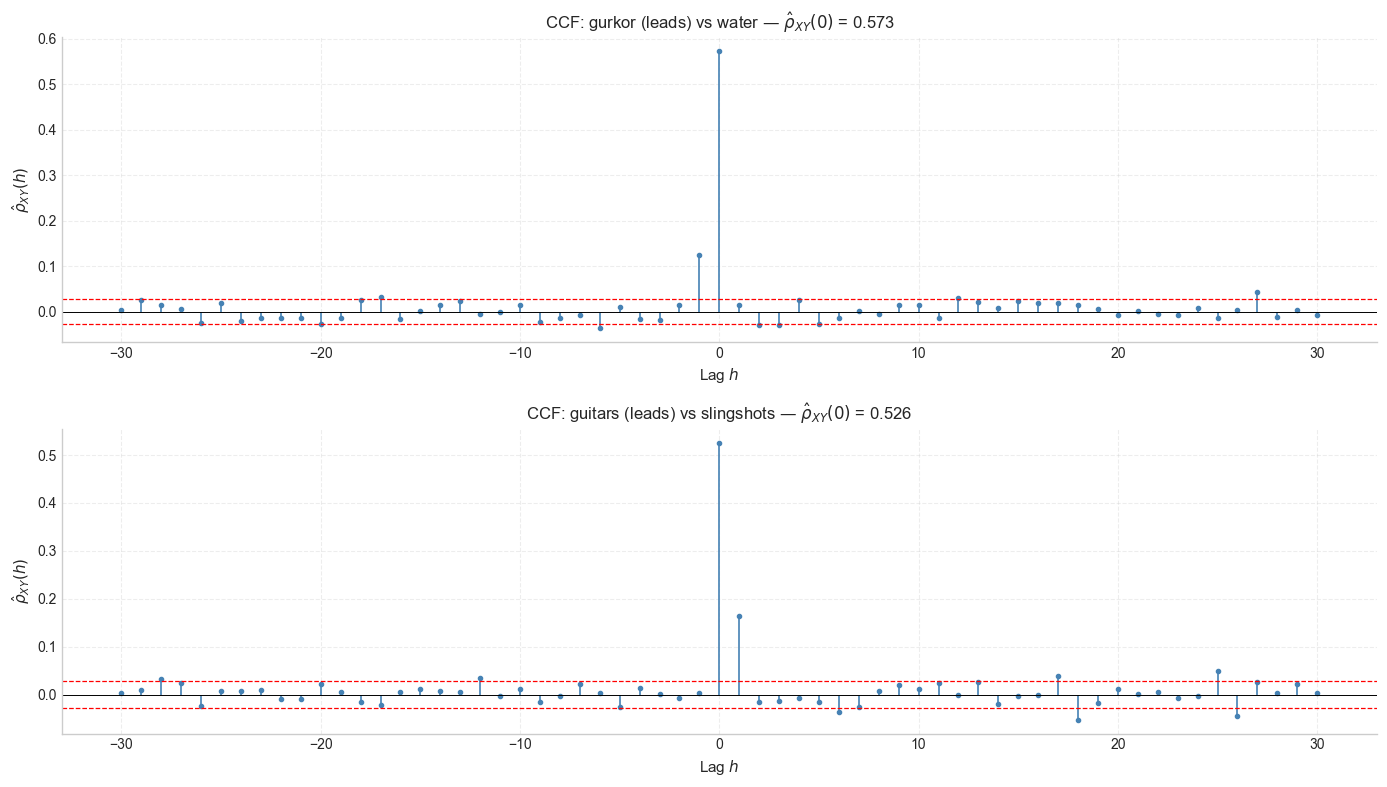

In [ ]:
MAX_LAG = 30
high_corr_pairs = [
    (s1, s2, corr_matrix.loc[s1, s2])
    for i, s1 in enumerate(SERIES)
    for j, s2 in enumerate(SERIES)
    if j > i and abs(corr_matrix.loc[s1, s2]) > 0.5
]

if high_corr_pairs:
    print("Pairs with |rho| > 0.5:")
    for s1, s2, rho in high_corr_pairs:
        print(f"  {s1} vs {s2}: rho = {rho:.3f}")

    fig, axes = plt.subplots(len(high_corr_pairs), 1,
                              figsize=(14, 4 * len(high_corr_pairs)))
    if len(high_corr_pairs) == 1:
        axes = [axes]

    for ax, (s1, s2, rho) in zip(axes, high_corr_pairs):
        r1 = returns_train[s1].dropna()
        r2 = returns_train[s2].dropna()
        idx = r1.index.intersection(r2.index)
        conf_ccf = 1.96 / np.sqrt(len(idx))

        ccf_pos = ccf(r1.loc[idx].values, r2.loc[idx].values,
                      nlags=MAX_LAG+1, adjusted=False)
        ccf_neg = ccf(r2.loc[idx].values, r1.loc[idx].values,
                      nlags=MAX_LAG+1, adjusted=False)

        all_lags = np.arange(-MAX_LAG, MAX_LAG + 1)
        all_ccf  = np.concatenate([ccf_neg[MAX_LAG:0:-1], ccf_pos])

        ax.vlines(all_lags, 0, all_ccf, colors='steelblue', lw=1.2)
        ax.plot(all_lags, all_ccf, 'o', ms=3, color='steelblue')
        ax.axhline( conf_ccf, ls='--', color='red', lw=0.9)
        ax.axhline(-conf_ccf, ls='--', color='red', lw=0.9)
        ax.axhline(0, color='black', lw=0.7)
        ax.set_title(rf'CCF: {s1} (leads) vs {s2} — $\hat{{\rho}}_{{XY}}(0)$ = {rho:.3f}')
        ax.set_xlabel('Lag $h$')
        ax.set_ylabel(r'$\hat{\rho}_{XY}(h)$')

    plt.tight_layout()
    plt.show()
else:
    print("No pairs with |rho| > 0.5 found in the training set.")

\
## 16. Grouping — hierarchical clustering

Ward linkage on the correlation-based distance matrix
$d_{ij} := 1 - |\hat{\rho}_{ij}|$.

**Caveat:** The dendrogram depends on the chosen linkage method (Ward used
here). It should be interpreted alongside the heatmap in Section 15, not as a
standalone conclusion. Clustering results in low-dimensional correlation data
are sensitive to sampling variability.\


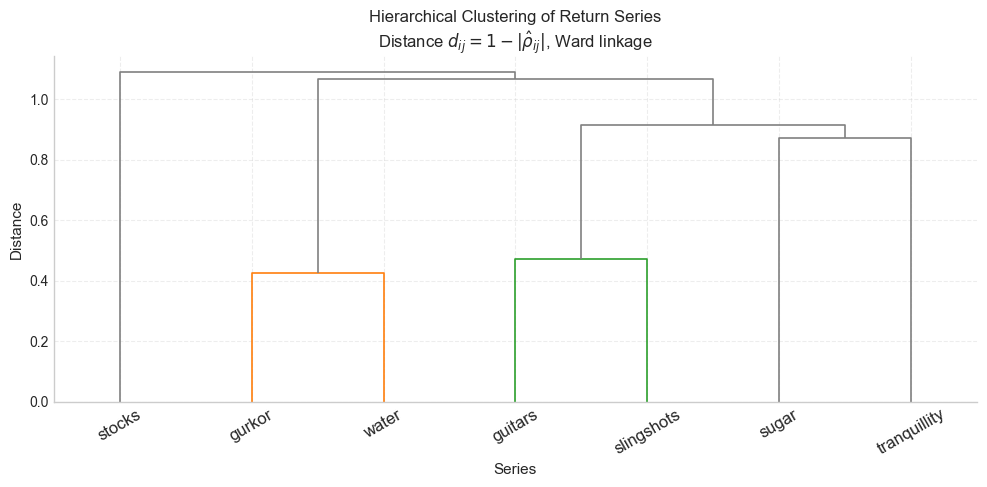

In [ ]:
dist_arr = (1 - corr_matrix.abs()).to_numpy().copy()
np.fill_diagonal(dist_arr, 0.0)
condensed = squareform(dist_arr, checks=False)
linked    = linkage(condensed, method='ward')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(linked, labels=SERIES, ax=ax,
           leaf_rotation=30, color_threshold=0.5,
           above_threshold_color='grey')
ax.set_title(
    'Hierarchical Clustering of Return Series\n'
    r'Distance $d_{ij} = 1 - |\hat{\rho}_{ij}|$, Ward linkage',
    fontsize=12)
ax.set_xlabel('Series')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

## 17. Results and interpretation

*(Complete after running the notebook. Summarise: gap locations, stationarity
conclusions, ACF/PACF patterns, ARCH effects, correlation structure, regime
shifts, and groupings.)*

## 18. Conclusions and caveats

*(Complete after running the notebook. State what is established with
confidence, what remains uncertain, and flag findings that may affect
Tasks 2, 3, or 4 — e.g. anomaly treatment, gap lengths, ARCH effects,
regime shifts, correlated pairs.)*